# Notebook 3: Reinforcement Learning for Fast Frequency Response

## Applied AI for Power and Energy Systems

This notebook demonstrates how reinforcement learning can be used for fast frequency response in a simplified power-system model.

We compare three cases:

1. No controller
2. Droop controller
3. Reinforcement learning controller

The RL controller is represented by a pretrained DDPG actor network.

## Learning objectives

By the end of this notebook, participants should be able to:

- Explain why frequency changes after a power imbalance.
- Describe the RL terms: environment, state, action, reward, policy, and episode.
- Simulate a simple frequency-response model.
- Compare no-control, droop-control, and RL-control responses.
- Fine-tune a partially trained RL model for a few short episodes.

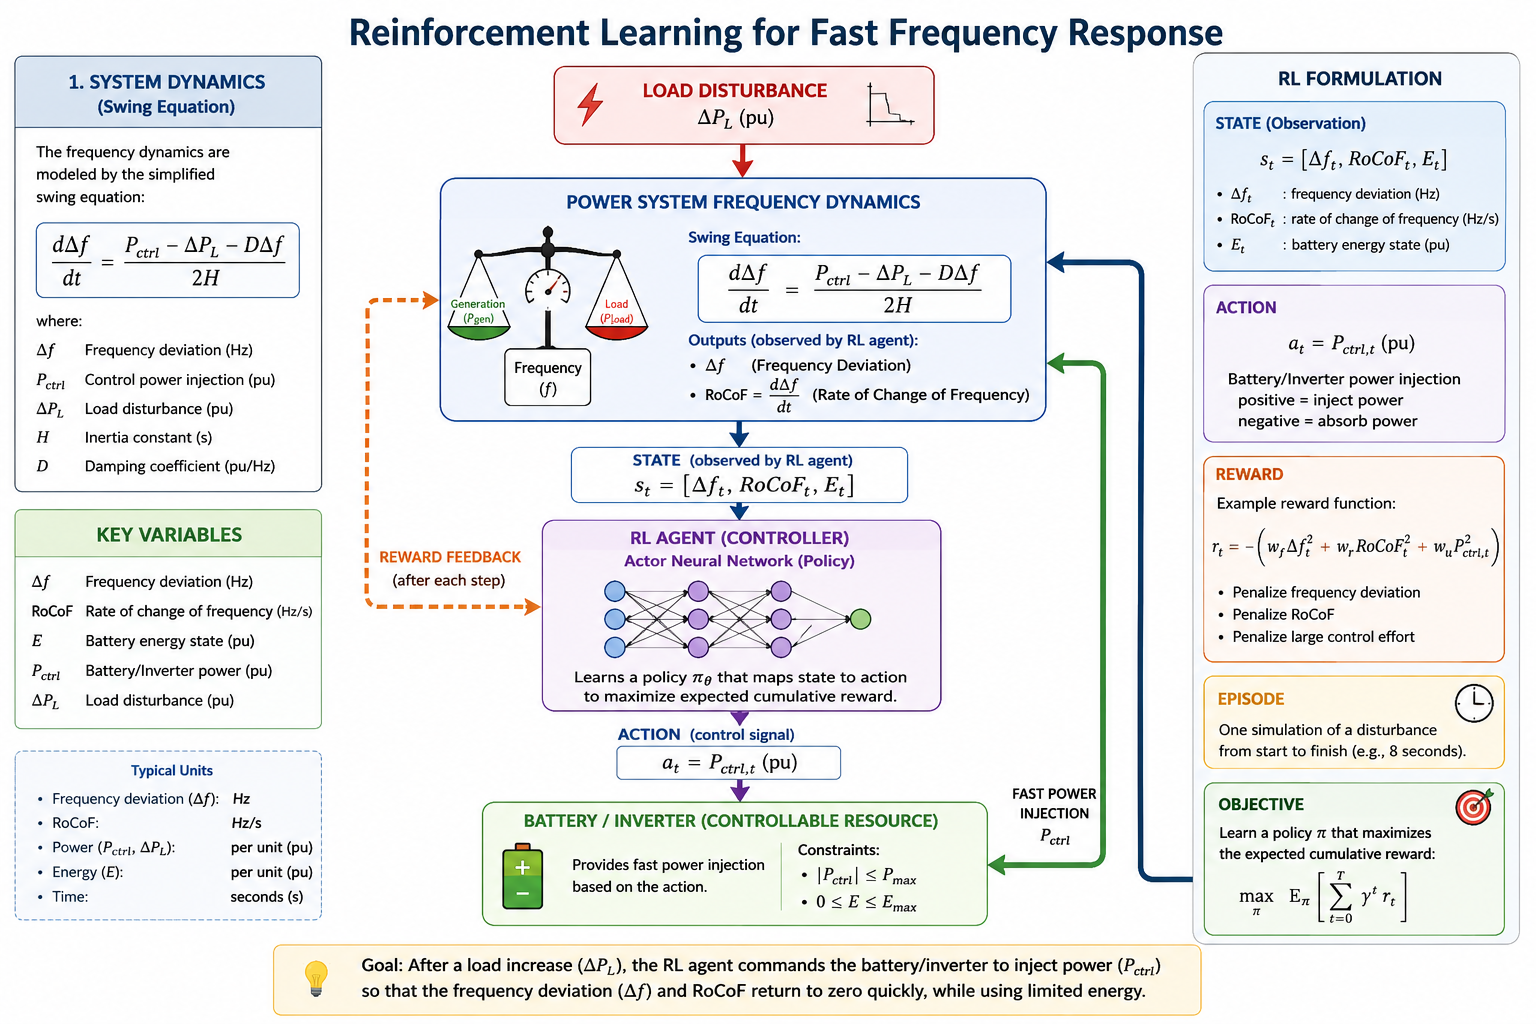

In [17]:
!pip install -q gymnasium

In [18]:
from google.colab import files
uploaded = files.upload()

Saving rl_frequency_workshop.zip to rl_frequency_workshop (1).zip


In [19]:
!unzip -o rl_frequency_workshop.zip
!ls -lah
!ls -lah src models notebooks

Archive:  rl_frequency_workshop.zip
  inflating: src/__pycache__/ddpg_agent.cpython-312.pyc  
  inflating: src/__pycache__/frequency_env.cpython-312.pyc  
  inflating: src/frequency_env.py    
  inflating: src/ddpg_agent.py       
  inflating: models/rl_training_curve.png  
  inflating: models/rl_actor_starting_point.pt  
  inflating: models/rl_critic_starting_point.pt  
  inflating: models/rl_actor_pretrained.pt  
  inflating: models/rl_critic_pretrained.pt  
  inflating: notebooks/03_rl_frequency_response.ipynb  
  inflating: train_rl_frequency_agent.py  
total 768K
drwxr-xr-x 1 root root 4.0K Jun 15 09:16  .
drwxr-xr-x 1 root root 4.0K Jun 15 08:20  ..
drwxr-xr-x 4 root root 4.0K Jun  4 13:32  .config
drwxr-xr-x 2 root root 4.0K Jun 15 08:42  .ipynb_checkpoints
drwxr-xr-x 2 root root 4.0K Jun 15 09:16  models
drwxr-xr-x 2 root root 4.0K Jun 15 09:16  notebooks
-rw-r--r-- 1 root root 364K Jun 15 09:16 'rl_frequency_workshop (1).zip'
-rw-r--r-- 1 root root 364K Jun 15 08:50  rl_freque

In [20]:
import os
import sys
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

sys.path.append("/content")
sys.path.append(".")

from src.frequency_env import FrequencyResponseEnv, droop_controller
from src.ddpg_agent import DDPGAgent, DDPGConfig

SEED = 469

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cpu



## 1. Background: fast frequency response

In an electric power system, generation and load must remain balanced.

When load suddenly increases, generation is temporarily insufficient. The system frequency begins to fall.

Fast frequency response uses controllable resources, such as batteries, inverter-based resources, or flexible loads, to inject power quickly and reduce the frequency deviation.

In this notebook, the controllable resource is modeled as an aggregated battery/inverter.

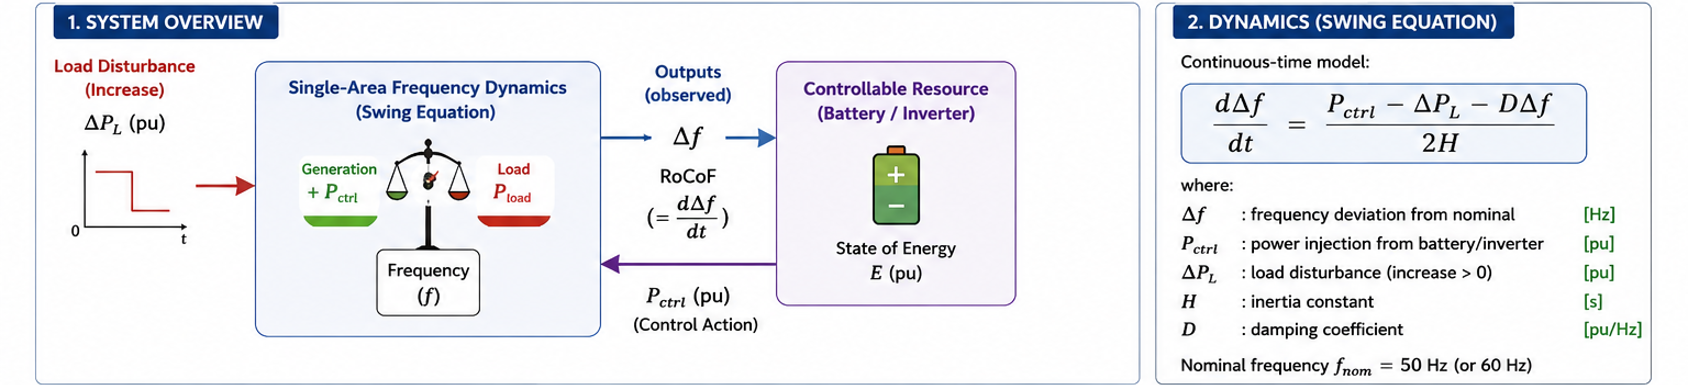

## 2. Simplified frequency model

We use a simplified single-area swing-equation model:

$$
\frac{d\Delta f}{dt}
=
\frac{P_{ctrl} - \Delta P_L - D\Delta f}{2H}
$$

where:

- $\Delta f$ is the frequency deviation in Hz,
- $P_{ctrl}$ is the controller power injection,
- $\Delta P_L$ is the disturbance or load increase,
- $H$ is the inertia constant,
- $D$ is the damping coefficient.

The RL agent observes:

$$
s_t = [\Delta f_t,\ RoCoF_t,\ E_t]
$$

and outputs:

$$
a_t = P_{ctrl}
$$

In [21]:
def make_env(seed=469):
    return FrequencyResponseEnv(
        dt=0.05,
        episode_time=8.0,
        H=5.0,
        D=1.0,
        p_ctrl_max=0.3,
        energy_init=1.0,
        energy_max=1.0,
        disturbance_range=(0.05, 0.25),
        disturbance_time_range=(0.5, 1.5),
        seed=seed,
    )


env = make_env(SEED)
obs, info = env.reset(seed=SEED)

print("Initial observation:", obs)
print("Disturbance magnitude:", info["disturbance"])
print("Disturbance time:", info["disturbance_time"])
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Initial observation: [0. 0. 1.]
Disturbance magnitude: 0.15101516949960725
Disturbance time: 1.4730576291397752
Observation space: Box([ -5. -10.   0.], [ 5. 10.  1.], (3,), float32)
Action space: Box(-0.3, 0.3, (1,), float32)


## 3. RL formulation

| RL term | Meaning in this notebook |
|---|---|
| Environment | Frequency dynamics model |
| State | Frequency deviation, RoCoF, battery energy |
| Action | Battery/inverter power injection |
| Reward | Penalty for frequency deviation, RoCoF, and excessive control effort |
| Episode | One disturbance simulation |
| Policy | Mapping from observed state to control action |

The RL agent learns a control policy through repeated interaction with the environment.

In [22]:
rl_agent = DDPGAgent(
    state_dim=3,
    action_dim=1,
    action_limit=0.3,
    device=device,
)

rl_agent.load(
    "models/rl_actor_pretrained.pt",
    "models/rl_critic_pretrained.pt",
)

print("Pretrained RL model loaded successfully.")

Pretrained RL model loaded successfully.


In [23]:
def simulate_controller(controller_type, seed=469, agent=None, k_droop=8.0):
    env = make_env(seed)
    state, info = env.reset(seed=seed)

    history = {
        "time": [],
        "freq": [],
        "rocof": [],
        "action": [],
        "energy": [],
        "reward": [],
        "disturbance": [],
    }

    done = False

    while not done:
        if controller_type == "none":
            action = np.array([0.0], dtype=np.float32)

        elif controller_type == "droop":
            action = droop_controller(
                state,
                k_droop=k_droop,
                p_ctrl_max=env.p_ctrl_max,
            )

        elif controller_type == "rl":
            action = agent.select_action(state, add_noise=False)

        else:
            raise ValueError("controller_type must be 'none', 'droop', or 'rl'.")

        next_state, reward, terminated, truncated, info_step = env.step(action)

        history["time"].append(info_step["time"])
        history["freq"].append(info_step["freq_dev"])
        history["rocof"].append(info_step["rocof"])
        history["action"].append(info_step["p_ctrl"])
        history["energy"].append(info_step["energy"])
        history["reward"].append(reward)
        history["disturbance"].append(info_step["p_dist"])

        state = next_state
        done = terminated or truncated

    return {key: np.array(value) for key, value in history.items()}

## 4. Simulate the three controllers

We now simulate the same disturbance under three control strategies.

In [24]:
results_none = simulate_controller("none", seed=SEED)
results_droop = simulate_controller("droop", seed=SEED, k_droop=8.0)
results_rl = simulate_controller("rl", seed=SEED, agent=rl_agent)

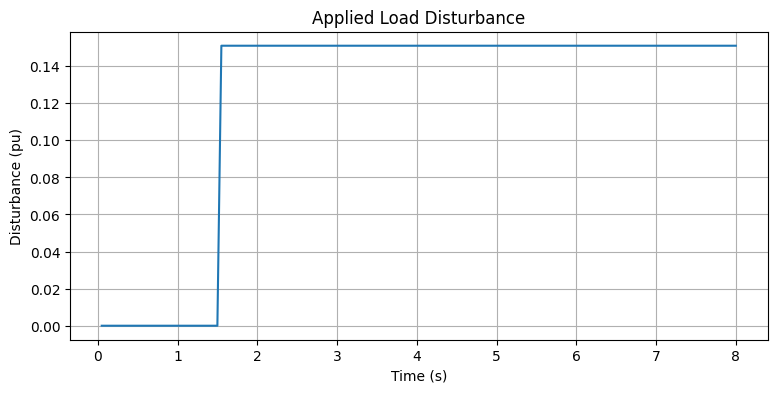

In [25]:
plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], results_none["disturbance"])
plt.xlabel("Time (s)")
plt.ylabel("Disturbance (pu)")
plt.title("Applied Load Disturbance")
plt.grid(True)
plt.show()

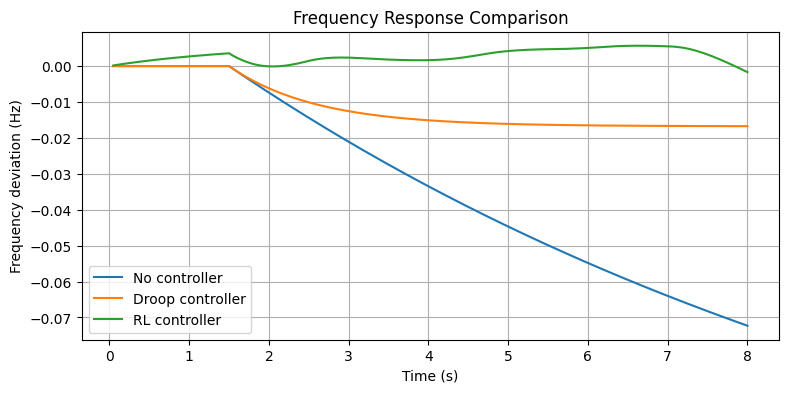

In [26]:
plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], results_none["freq"], label="No controller")
plt.plot(results_droop["time"], results_droop["freq"], label="Droop controller")
plt.plot(results_rl["time"], results_rl["freq"], label="RL controller")
plt.xlabel("Time (s)")
plt.ylabel("Frequency deviation (Hz)")
plt.title("Frequency Response Comparison")
plt.grid(True)
plt.legend()
plt.show()

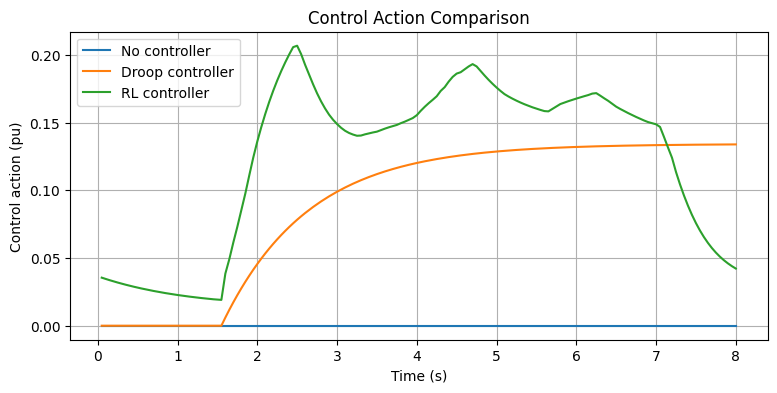

In [27]:
plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], results_none["action"], label="No controller")
plt.plot(results_droop["time"], results_droop["action"], label="Droop controller")
plt.plot(results_rl["time"], results_rl["action"], label="RL controller")
plt.xlabel("Time (s)")
plt.ylabel("Control action (pu)")
plt.title("Control Action Comparison")
plt.grid(True)
plt.legend()
plt.show()

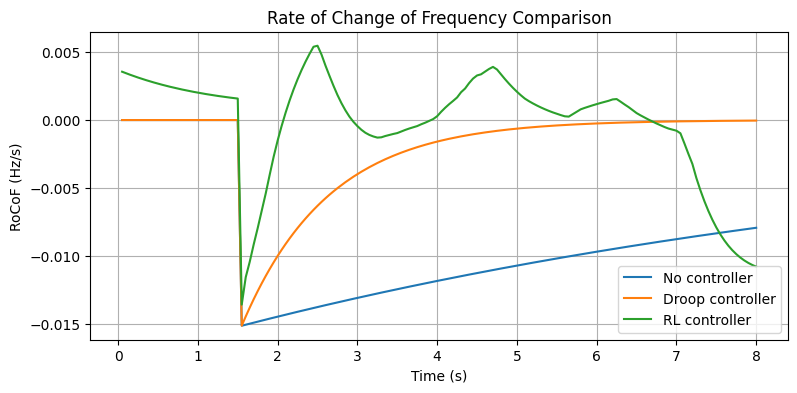

In [28]:
plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], results_none["rocof"], label="No controller")
plt.plot(results_droop["time"], results_droop["rocof"], label="Droop controller")
plt.plot(results_rl["time"], results_rl["rocof"], label="RL controller")
plt.xlabel("Time (s)")
plt.ylabel("RoCoF (Hz/s)")
plt.title("Rate of Change of Frequency Comparison")
plt.grid(True)
plt.legend()
plt.show()

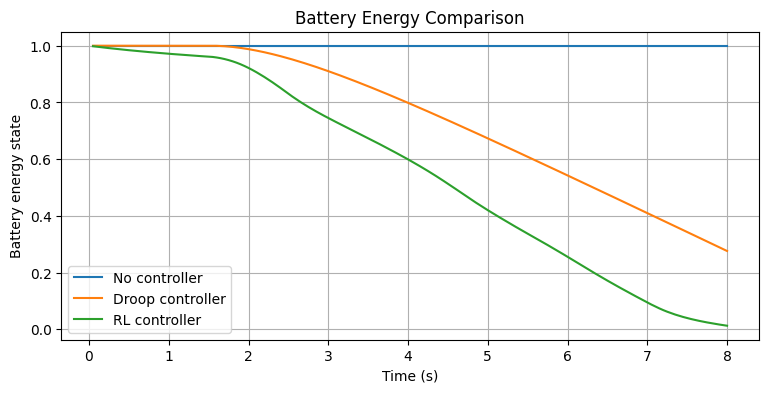

In [29]:
plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], results_none["energy"], label="No controller")
plt.plot(results_droop["time"], results_droop["energy"], label="Droop controller")
plt.plot(results_rl["time"], results_rl["energy"], label="RL controller")
plt.xlabel("Time (s)")
plt.ylabel("Battery energy state")
plt.title("Battery Energy Comparison")
plt.grid(True)
plt.legend()
plt.show()

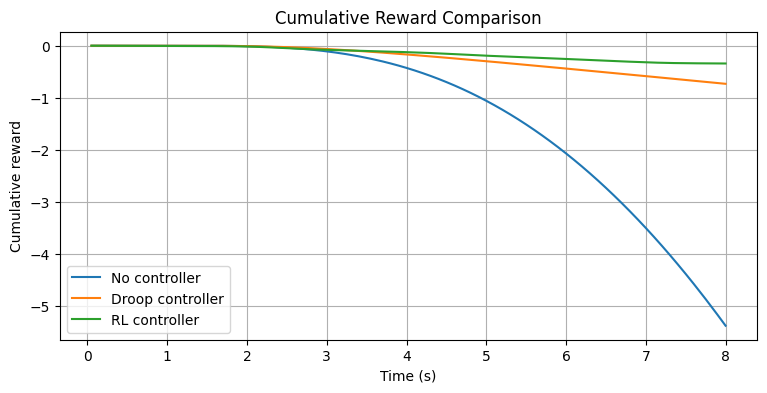

In [30]:
plt.figure(figsize=(9, 4))
plt.plot(results_none["time"], np.cumsum(results_none["reward"]), label="No controller")
plt.plot(results_droop["time"], np.cumsum(results_droop["reward"]), label="Droop controller")
plt.plot(results_rl["time"], np.cumsum(results_rl["reward"]), label="RL controller")
plt.xlabel("Time (s)")
plt.ylabel("Cumulative reward")
plt.title("Cumulative Reward Comparison")
plt.grid(True)
plt.legend()
plt.show()

## 5. Summary metrics

We compute simple performance metrics for the three controllers.

In [31]:
def summarize(name, results):
    return {
        "Controller": name,
        "Minimum frequency deviation (Hz)": np.min(results["freq"]),
        "Final frequency deviation (Hz)": results["freq"][-1],
        "Maximum absolute action (pu)": np.max(np.abs(results["action"])),
        "Total reward": np.sum(results["reward"]),
    }


summary_df = pd.DataFrame([
    summarize("No controller", results_none),
    summarize("Droop controller", results_droop),
    summarize("RL controller", results_rl),
])

summary_df

,Controller,Minimum frequency deviation (Hz),Final frequency deviation (Hz),Maximum absolute action (pu),Total reward
0,No controller,-0.072307,-0.072307,0.000000,-5.381426
1,Droop controller,-0.016737,-0.016737,0.133882,-0.732035
2,RL controller,-0.001690,-0.001690,0.206753,-0.341555


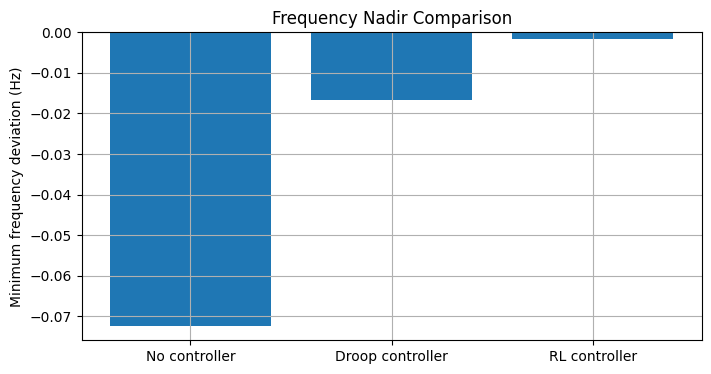

In [32]:
plt.figure(figsize=(8, 4))
plt.bar(summary_df["Controller"], summary_df["Minimum frequency deviation (Hz)"])
plt.ylabel("Minimum frequency deviation (Hz)")
plt.title("Frequency Nadir Comparison")
plt.grid(True)
plt.show()

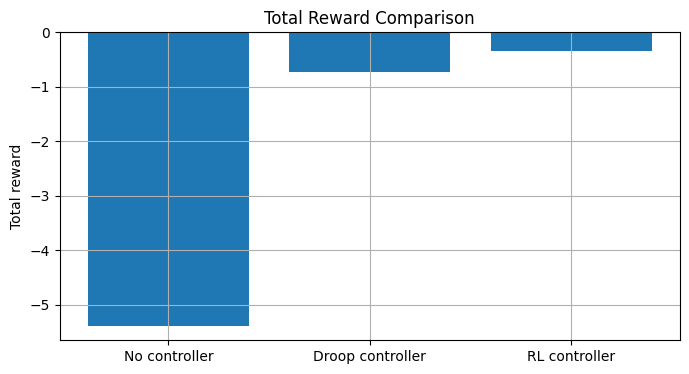

In [33]:
plt.figure(figsize=(8, 4))
plt.bar(summary_df["Controller"], summary_df["Total reward"])
plt.ylabel("Total reward")
plt.title("Total Reward Comparison")
plt.grid(True)
plt.show()

## 6. Training curve

The DDPG agent was trained using the separate file:

```text
train_rl_frequency_agent.py

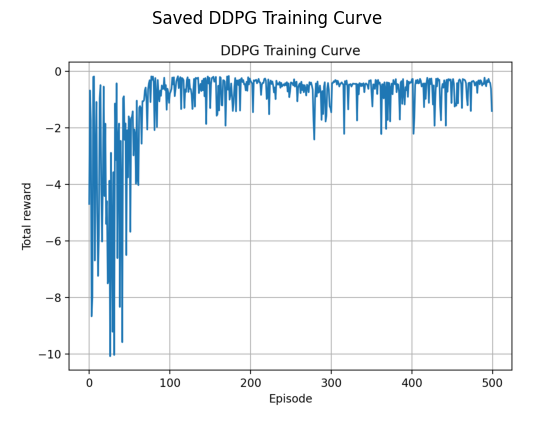

In [37]:
training_curve_path = "models/rl_training_curve.png"

if os.path.exists(training_curve_path):
    img = plt.imread(training_curve_path)
    plt.figure(figsize=(9, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Saved DDPG Training Curve")
    plt.show()
else:
    print("Training curve image not found.")

## 7. Participant exercise: fine-tune a starting-point model

Participants now load a partially trained model and fine-tune it for a small number of episodes.

This is not full training from scratch. It is a short demonstration of the RL training loop.

In [38]:
student_agent = DDPGAgent(
    state_dim=3,
    action_dim=1,
    action_limit=0.3,
    device=device,
    config=DDPGConfig(
        gamma=0.99,
        tau=0.005,
        actor_lr=1e-4,
        critic_lr=1e-3,
        batch_size=128,
        replay_capacity=100_000,
        exploration_noise=0.05,
    ),
)

student_agent.load(
    "models/rl_actor_starting_point.pt",
    "models/rl_critic_starting_point.pt",
)

print("Starting-point model loaded.")

Starting-point model loaded.


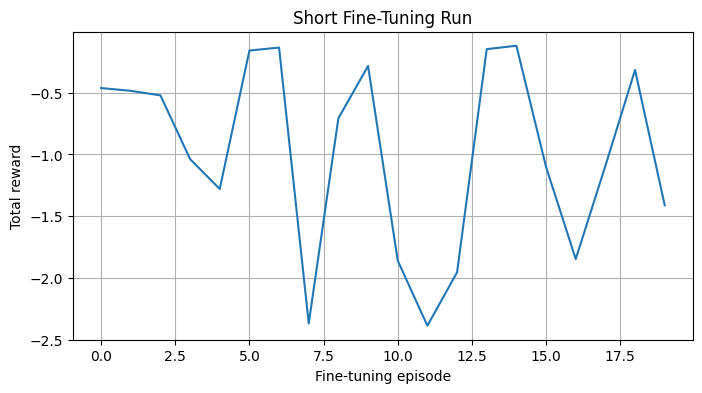

In [39]:
def fine_tune(agent, n_episodes=20):
    episode_rewards = []

    for episode in range(1, n_episodes + 1):
        env = make_env(seed=SEED + episode)
        state, info = env.reset(seed=SEED + episode)

        total_reward = 0.0
        done = False

        while not done:
            action = agent.select_action(state, add_noise=True)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            agent.replay_buffer.push(
                state,
                action,
                reward,
                next_state,
                float(done),
            )

            agent.update()

            state = next_state
            total_reward += reward

        episode_rewards.append(total_reward)

    return episode_rewards


N_FINE_TUNE_EPISODES = 20
fine_tune_rewards = fine_tune(student_agent, n_episodes=N_FINE_TUNE_EPISODES)

plt.figure(figsize=(8, 4))
plt.plot(fine_tune_rewards)
plt.xlabel("Fine-tuning episode")
plt.ylabel("Total reward")
plt.title("Short Fine-Tuning Run")
plt.grid(True)
plt.show()

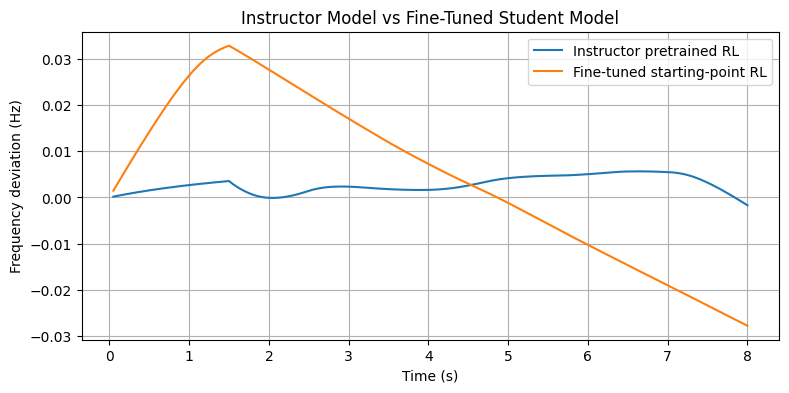

In [40]:
results_student = simulate_controller("rl", seed=SEED, agent=student_agent)

plt.figure(figsize=(9, 4))
plt.plot(results_rl["time"], results_rl["freq"], label="Instructor pretrained RL")
plt.plot(results_student["time"], results_student["freq"], label="Fine-tuned starting-point RL")
plt.xlabel("Time (s)")
plt.ylabel("Frequency deviation (Hz)")
plt.title("Instructor Model vs Fine-Tuned Student Model")
plt.grid(True)
plt.legend()
plt.show()

## 8. Discussion

The RL controller can learn a mapping from frequency state to power injection.

However, RL is not automatically safe for real power systems. Important practical issues include:

- inverter power limits,
- battery state-of-charge limits,
- reward design,
- robustness to unseen disturbances,
- safety constraints,
- validation before deployment.

This example is intentionally simplified for teaching.

## 9. Next steps

Possible extensions include:

- Soft Actor-Critic instead of DDPG,
- multi-area frequency dynamics,
- grid-forming inverter models,
- battery degradation constraints,
- stochastic renewable generation,
- multi-agent RL for distributed energy resources,
- safety-constrained RL,
- hardware-in-the-loop validation.